In [8]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


parameter w :
 [[3.94188011]
 [8.73592461]]


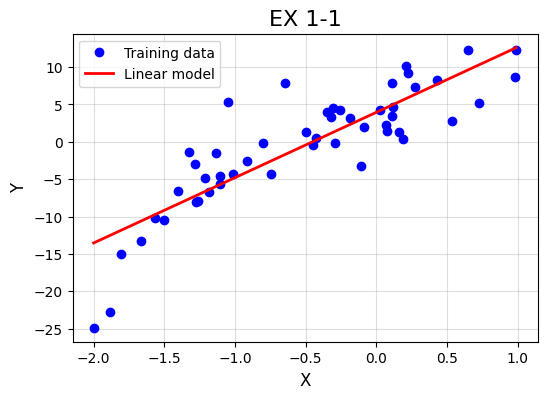

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#1. 최소제곱법을 이용한 예측

x=pd.read_csv('/content/drive/MyDrive/data0405.csv', usecols=['x']).values
y=pd.read_csv('/content/drive/MyDrive/data0405.csv', usecols=['y']).values

A = np.hstack([x**0, x])
A = np.asmatrix(A)
#print('A :\n', A)

# 학습 데이터

w = (A.T*A).I*A.T*y
print('parameter w :\n', w)
plt.figure(figsize = (6, 4))
plt.title('EX 1-1', fontsize = 16)
plt.xlabel('X', fontsize = 12)
plt.ylabel('Y', fontsize = 12)
plt.plot(x, y, 'bo', label = "Training data")

# 선형모델 plotting (최소제곱법)
xp = np.arange(-2, 1, 0.01).reshape(-1, 1)
yp = w[0,0] + w[1,0]*xp
#print(yp)
plt.plot(xp, yp, 'r', linewidth = 2, label = "Linear model")
plt.legend()
plt.grid(alpha = 0.4)
plt.show()

[[ 5.03906362]
 [ 5.27924916]
 [-3.31676315]]


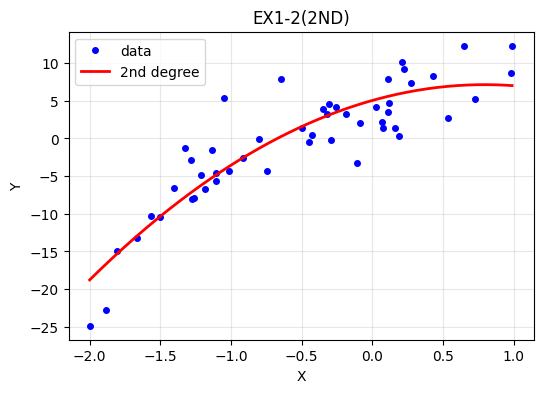

In [21]:
#1-2
A = np.hstack([x**0, x,  x**2])
A = np.asmatrix(A)

w = (A.T*A).I*A.T*y
print(w)

xp = np.arange(-2.0, 1.0, 0.01).reshape(-1, 1)
yp = w[0,0] + w[1,0]*xp + w[2,0]*xp**2

plt.figure(figsize = (6, 4))
plt.plot(x, y, 'bo', markersize = 4, label = "data")
plt.plot(xp[:,0], yp[:,0], 'r', linewidth = 2, label = '2nd degree')
plt.title('EX1-2(2ND)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()



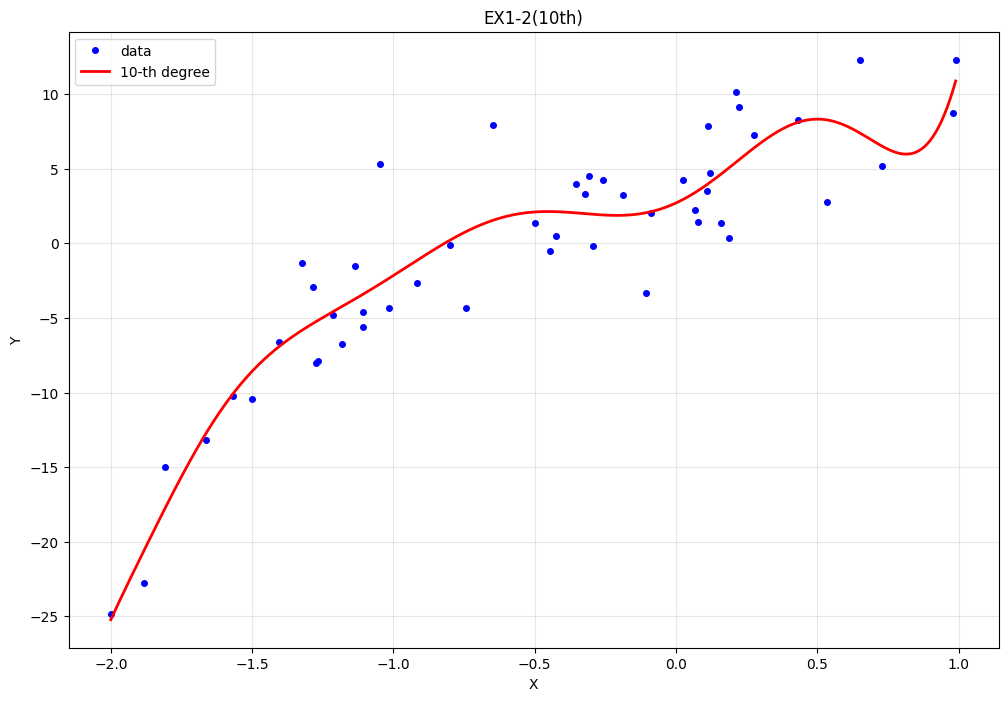

In [22]:
d=11
xp = np.arange(-2.0, 1.0, 0.01).reshape(-1, 1)
polybasis = np.hstack([xp**i for i in range(d)])
polybasis = np.asmatrix(polybasis)

# w를 구하는 과정
A = np.hstack([x**i for i in range(d)])
A = np.asmatrix(A)
w = (A.T*A).I*A.T*y  # 학습(최소제곱법)

yp = polybasis*w  # polybasis 함수와 w의 선형 결합

plt.figure(figsize = (12, 8))
plt.plot(x, y, 'bo', markersize = 4, label = "data")
plt.plot(xp[:,0], yp[:,0], 'r', linewidth = 2, label = '{}-th degree'.format(d-1))
plt.title('EX1-2(10th)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

[2.23603262] [0.06825886]


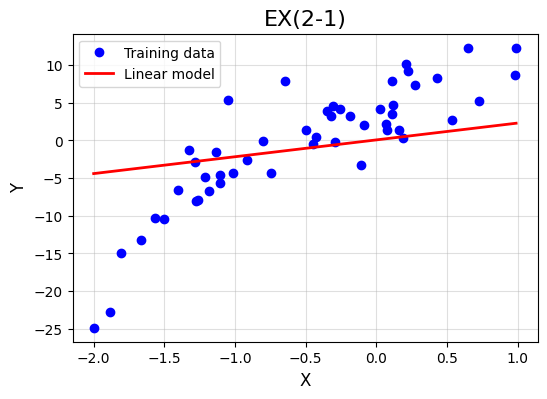

In [23]:
A = np.hstack([x**0, x])  # data x의 앞에 1을 horizontal 방향으로 추가
A = np.asmatrix(A)
# print('A :\n', A)

w1 = 0       # 기울기
w0 = 0       # 절편

lrate = 0.001  # 학습률(Learning rate) --> α
epochs = 500  # 반복 횟수

n = float(len(x)) # 입력 데이터의 개수

# 경사 하강법
for i in range(epochs):
    y_pred = w1*x + w0  		          	# 선형 회귀 예측값
    dw1 = (1/n) * sum(x * (y_pred-y)) 	# 넘파이 배열간의 산술 계산은 요소별로 적용
    dw0 = (1/n) * sum(y_pred-y)  	      # sum()은 모든 요소들의 합을 계산하는 내장 함수
    w1 = w1 - lrate * dw1           		# 기울기 update
    w0 = w0 - lrate * dw0  		          # 절편 update
print (w1, w0)

# 학습 데이터 그래프
plt.figure(figsize = (6, 4))
plt.title('EX(2-1)', fontsize = 16)
plt.xlabel('X', fontsize = 12)
plt.ylabel('Y', fontsize = 12)
plt.plot(x, y, 'bo', label = "Training data")

xp = np.arange(-2.0, 1.0, 0.01).reshape(-1, 1)
y_pred = w1*xp + w0  # 예측값을 만든다.
#print(y_pred)
plt.plot(xp, y_pred, 'r', linewidth = 2, label = "Linear model")
plt.legend()
plt.grid(alpha = 0.4)
plt.show()

[[ 5.03915533]
 [ 5.27863524]
 [-3.31721588]]


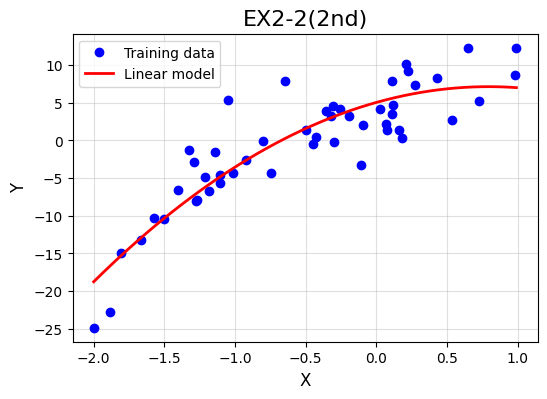

In [44]:
K = 2 # 2차

# 디자인 행렬 A 구성: [1, x, x^2, ..., x^degree]
A = np.hstack([x**i for i in range(K + 1)])
A = np.asmatrix(A)
m = y.shape[0]

# 파라미터 초기화
w = np.random.randn(K + 1, 1)
w = np.asmatrix(w)


alpha = 0.001
epochs = 500

# 경사하강법 수행
for _ in range(epochs):
    dJ = 2 * (A.T * A * w - A.T * y)
    w = w - alpha * dJ

# 결과 출력
print(w)

# 예측용 데이터 및 결과 계산
xp = np.linspace(np.min(x), np.max(x)).reshape(-1, 1)
Ap = np.hstack([xp**i for i in range(K + 1)])
Ap = np.asmatrix(Ap)
yp = Ap * w

plt.figure(figsize = (6, 4))
plt.title('EX2-2(2nd)', fontsize = 16)
plt.xlabel('X', fontsize = 12)
plt.ylabel('Y', fontsize = 12)
plt.plot(x, y, 'bo', label = "Training data")

#print(yp)
plt.plot(xp, yp, 'r', linewidth = 2, label = "Linear model")
plt.legend()
plt.grid(alpha = 0.4)
plt.show()

[[ 3.78365653e+23]
 [-5.64918740e+23]
 [ 9.34637328e+23]
 [-1.57692870e+24]
 [ 2.76886149e+24]]


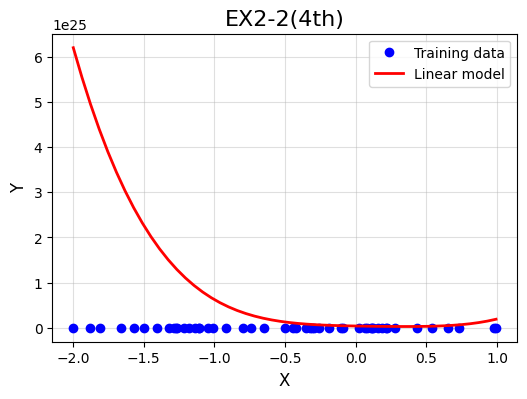

In [46]:
K = 4 # 2차

# 디자인 행렬 A 구성: [1, x, x^2, ..., x^degree]
A = np.hstack([x**i for i in range(K + 1)])
A = np.asmatrix(A)
m = y.shape[0]

# 파라미터 초기화
w = np.random.randn(K + 1, 1)
w = np.asmatrix(w)


alpha = 0.001
epochs = 500

# 경사하강법 수행
for _ in range(epochs):
    dJ = 2 * (A.T * A * w - A.T * y)
    w = w - alpha * dJ

# 결과 출력
print(w)

# 예측용 데이터 및 결과 계산
xp = np.linspace(np.min(x), np.max(x)).reshape(-1, 1)
Ap = np.hstack([xp**i for i in range(K + 1)])
Ap = np.asmatrix(Ap)
yp = Ap * w

plt.figure(figsize = (6, 4))
plt.title('EX2-2(4th)', fontsize = 16)
plt.xlabel('X', fontsize = 12)
plt.ylabel('Y', fontsize = 12)
plt.plot(x, y, 'bo', label = "Training data")

#print(yp)
plt.plot(xp, yp, 'r', linewidth = 2, label = "Linear model")
plt.legend()
plt.grid(alpha = 0.4)
plt.show()